# 지하철 유동인구 기반 고객 접근성이 서울시 청소년게임제공업 생존에 미치는 영향 분석

**연구 질문:** 서울시 청소년게임제공업에서 고객 접근성(유동인구, 역 거리)이 업소 생존에 미치는 영향은 무엇인가?

In [1]:
## 0. 라이브러리 임포트
import pandas as pd
import requests
import time
import glob
from pyproj import Transformer
from haversine import haversine, Unit
import re
import plotly.express as px
import json
import folium

### 수집

In [2]:
## 1. 데이터 수집
# 서울시 청소년 게임제공업 데이터 불러오기

doc = pd.read_csv("문화_청소년게임제공업_서울특별시.csv", encoding='cp949')
doc.tail()

,개방자치단체코드,관리번호,인허가일자,인허가취소일자,영업상태명,폐업일자,휴업시작일자,휴업종료일자,소재지우편번호,도로명우편번호,...,지역구분명,지하층수,청소년실수,청소년실여부,총게임기수,총층수,통로너비,특수조명여부,편의시설여부,최종수정시점
4059,3240000,CDFF2241142020000003,2020-04-06,NaN,영업/정상,NaN,NaN,NaN,NaN,5333.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020-04-06 09:23:49
4060,3240000,CDFF2241142020000005,2020-05-06,NaN,영업/정상,NaN,NaN,NaN,NaN,5335.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023-08-14 18:50:51
4061,3240000,CDFF2241142020000006,2020-05-14,NaN,영업/정상,NaN,NaN,NaN,NaN,5265.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-02-07 15:00:14
4062,3240000,CDFF2241142023000001,2023-01-16,NaN,영업/정상,NaN,NaN,NaN,NaN,5335.0,...,일반상업지역,NaN,NaN,NaN,12.0,NaN,NaN,NaN,NaN,2023-01-16 16:12:43
4063,3240000,CDFF2241142023000002,2023-08-11,NaN,영업/정상,NaN,NaN,NaN,NaN,5335.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-10-23 16:10:17


In [3]:
# 행 갯수 확인
doc.shape

(4064, 50)

In [4]:
# 데이터 타입 등 정보 확인
doc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4064 entries, 0 to 4063
Data columns (total 50 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   개방자치단체코드   4064 non-null   int64  
 1   관리번호       4064 non-null   object 
 2   인허가일자      4064 non-null   object 
 3   인허가취소일자    738 non-null    object 
 4   영업상태명      4064 non-null   object 
 5   폐업일자       2334 non-null   object 
 6   휴업시작일자     6 non-null      object 
 7   휴업종료일자     6 non-null      object 
 8   소재지우편번호    226 non-null    object 
 9   도로명우편번호    2208 non-null   float64
 10  사업장명       4064 non-null   object 
 11  데이터갱신구분    4064 non-null   object 
 12  건물용도명      1303 non-null   object 
 13  기존게임업외업종명  1 non-null      object 
 14  노래방실수      0 non-null      float64
 15  데이터갱신시점    4064 non-null   object 
 16  도로명주소      3958 non-null   object 
 17  문화사업자구분명   4064 non-null   object 
 18  문화체육업종명    4064 non-null   object 
 19  방음시설여부     0 non-null      float64
 20  비디오재생기명 

In [5]:
# 결측치 확인
doc.isnull().sum()

개방자치단체코드        0
관리번호            0
인허가일자           0
인허가취소일자      3326
영업상태명           0
폐업일자         1730
휴업시작일자       4058
휴업종료일자       4058
소재지우편번호      3838
도로명우편번호      1856
사업장명            0
데이터갱신구분         0
건물용도명        2761
기존게임업외업종명    4063
노래방실수        4064
데이터갱신시점         0
도로명주소         106
문화사업자구분명        0
문화체육업종명         0
방음시설여부       4064
비디오재생기명      4064
비상계단여부       4064
비상구여부        4064
상세영업상태명         0
상세영업상태코드        0
소방시설여부       4064
시설면적           18
영업상태코드          0
음향시설여부       4064
자동환기여부       4064
전화번호         3925
제공게임물명        238
제작취급품목내용     1709
조명시설유무       4064
조명시설조도       3911
좌표정보(X)        59
좌표정보(Y)        59
주변환경명        3249
지번주소           16
지상층수         2784
지역구분명        2986
지하층수         3151
청소년실수        4064
청소년실여부       4064
총게임기수        2035
총층수          2950
통로너비         4064
특수조명여부       4064
편의시설여부       4064
최종수정시점          0
dtype: int64

In [6]:
# 컬럼 확인
print(doc.columns.tolist())

['개방자치단체코드', '관리번호', '인허가일자', '인허가취소일자', '영업상태명', '폐업일자', '휴업시작일자', '휴업종료일자', '소재지우편번호', '도로명우편번호', '사업장명', '데이터갱신구분', '건물용도명', '기존게임업외업종명', '노래방실수', '데이터갱신시점', '도로명주소', '문화사업자구분명', '문화체육업종명', '방음시설여부', '비디오재생기명', '비상계단여부', '비상구여부', '상세영업상태명', '상세영업상태코드', '소방시설여부', '시설면적', '영업상태코드', '음향시설여부', '자동환기여부', '전화번호', '제공게임물명', '제작취급품목내용', '조명시설유무', '조명시설조도', '좌표정보(X)', '좌표정보(Y)', '주변환경명', '지번주소', '지상층수', '지역구분명', '지하층수', '청소년실수', '청소년실여부', '총게임기수', '총층수', '통로너비', '특수조명여부', '편의시설여부', '최종수정시점']


### 전처리

In [7]:
## 2. 전처리
# 필요한 컬럼만 정리

df = doc[['영업상태명','인허가일자','폐업일자','시설면적','총게임기수','좌표정보(X)','좌표정보(Y)','지번주소','도로명주소','상세영업상태명']].copy()
df

,영업상태명,인허가일자,폐업일자,시설면적,총게임기수,좌표정보(X),좌표정보(Y),지번주소,도로명주소,상세영업상태명
0,취소/말소/만료/정지/중지,2008-07-23,2013-07-05,214.50,70.0,198713.721333,452278.103939,서울특별시 종로구 인사동 170 (1층),"서울특별시 종로구 인사동길 23 (인사동,(1층))",직권말소
1,폐업,2019-06-13,2023-08-31,24.94,13.0,201742.998482,452496.336089,서울특별시 종로구 숭인동 183-9 정우빌딩,"서울특별시 종로구 종로 389, 정우빌딩 1층 (숭인동)",폐업
2,취소/말소/만료/정지/중지,2012-01-19,2013-07-05,85.05,NaN,201089.989130,452192.646041,서울특별시 종로구 창신동 378,"서울특별시 종로구 종로 318, 1층 (창신동)",직권말소
3,취소/말소/만료/정지/중지,2012-06-04,2022-12-16,181.10,20.0,198731.246361,451962.636141,서울특별시 종로구 종로2가 75-6 지하1층,"서울특별시 종로구 종로 80-2, 지하1층 (종로2가)",직권말소
4,취소/말소/만료/정지/중지,2016-09-28,2022-07-29,80.99,NaN,198790.560877,451962.812629,서울특별시 종로구 종로2가 71-5 1층,"서울특별시 종로구 종로 86-1, 1층 (종로2가)",직권말소
...,...,...,...,...,...,...,...,...,...,...
4059,영업/정상,2020-04-06,NaN,26.44,NaN,211513.329546,448506.440031,서울특별시 강동구 천호동 166-20 나호,"서울특별시 강동구 진황도로 35, 1층 나호 (천호동)",영업중
4060,영업/정상,2020-05-06,NaN,171.64,NaN,211156.236785,448427.428815,"서울특별시 강동구 천호동 453-18 1,5호","서울특별시 강동구 천호대로157길 6, 1,5호 (천호동)",영업중
4061,영업/정상,2020-05-14,NaN,22.18,NaN,211627.268273,449555.304475,서울특별시 강동구 암사동 490-56,"서울특별시 강동구 상암로 83, 1층 (암사동)",영업중
4062,영업/정상,2023-01-16,NaN,42.90,12.0,211220.108222,448503.534642,서울특별시 강동구 천호동 453-7,"서울특별시 강동구 천호대로159길 25, 1층 (천호동)",영업중


In [8]:
## 2-1. 영업상태 영업/폐업 분류
# 영업상태 확인
print(df['영업상태명'].value_counts())
print(df['상세영업상태명'].value_counts())

영업상태명
폐업                1987
취소/말소/만료/정지/중지    1095
영업/정상              980
제외/삭제/전출             2
Name: count, dtype: int64
상세영업상태명
폐업      1987
영업중      980
등록취소     742
직권말소     347
영업정지       6
전출         2
Name: count, dtype: int64


In [9]:
# 영업중 (980개) / 폐업 (1987개) / 등록취소 + 직권말소 (1089개) -> 관할 기관에서 폐업처리  / 영업정지(6개), 전출(2개)
# 영업정지(6개), 전출(2개)은 분석 대상에서 제외, 등록취소 + 직권말소는 실질적 영업 종료 상태로 판단하여 '폐업'으로 분류하기로함

영업중 = ['영업중']
폐업 = ['폐업','등록취소','직권말소']
제외 = ['영업정지','전출']

# 상세영업상태명에 '제외' 그룹 제외 '영업중','폐업'만 유지
df = df[~df['상세영업상태명'].isin(제외)]

# 폐업','등록취소','직권말소'면 1, '영업중'이면 0으로 표기
df['폐업여부'] = df['상세영업상태명'].isin(['폐업','등록취소','직권말소']).astype(int)

df.tail()

C:\Users\vhflv\AppData\Local\Temp\ipykernel_7504\165299989.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['폐업여부'] = df['상세영업상태명'].isin(['폐업','등록취소','직권말소']).astype(int)


,영업상태명,인허가일자,폐업일자,시설면적,총게임기수,좌표정보(X),좌표정보(Y),지번주소,도로명주소,상세영업상태명,폐업여부
4059,영업/정상,2020-04-06,NaN,26.44,NaN,211513.329546,448506.440031,서울특별시 강동구 천호동 166-20 나호,"서울특별시 강동구 진황도로 35, 1층 나호 (천호동)",영업중,0
4060,영업/정상,2020-05-06,NaN,171.64,NaN,211156.236785,448427.428815,"서울특별시 강동구 천호동 453-18 1,5호","서울특별시 강동구 천호대로157길 6, 1,5호 (천호동)",영업중,0
4061,영업/정상,2020-05-14,NaN,22.18,NaN,211627.268273,449555.304475,서울특별시 강동구 암사동 490-56,"서울특별시 강동구 상암로 83, 1층 (암사동)",영업중,0
4062,영업/정상,2023-01-16,NaN,42.90,12.0,211220.108222,448503.534642,서울특별시 강동구 천호동 453-7,"서울특별시 강동구 천호대로159길 25, 1층 (천호동)",영업중,0
4063,영업/정상,2023-08-11,NaN,193.02,NaN,211218.957284,448493.145289,서울특별시 강동구 천호동 453-8 원방빌딩,"서울특별시 강동구 천호대로157길 18, 원방빌딩 102호 (천호동)",영업중,0


In [10]:
# '폐업 여부' 컬럼 값 확인 > 폐업 1, 영업중 0
print(df['폐업여부'].value_counts())

폐업여부
1    3076
0     980
Name: count, dtype: int64


In [11]:
# 최종 데이터 수 확인
print(f'최종 데이터 수: {len(df)}')

최종 데이터 수: 4056


In [12]:
## 2-2. 시군구 추출
# '지번주소' 확인
print(df['지번주소'].tail(10))

4054        서울특별시 강동구 성내동 118-36 
4055         서울특별시 강동구 천호동 550-9 
4056        서울특별시 강동구 성내동 417-10 
4057         서울특별시 강동구 성내동 12-38 
4058      서울특별시 강동구 둔촌동 489 원천빌딩 
4059      서울특별시 강동구 천호동 166-20 나호
4060    서울특별시 강동구 천호동 453-18 1,5호
4061        서울특별시 강동구 암사동 490-56 
4062         서울특별시 강동구 천호동 453-7 
4063    서울특별시 강동구 천호동 453-8 원방빌딩 
Name: 지번주소, dtype: object


In [13]:
# split으로 구 이름만 가져오기
df['시군구'] = df['지번주소'].str.split().str[1]
print(df['시군구'].value_counts())

시군구
강서구     285
관악구     277
영등포구    269
송파구     222
성북구     216
강북구     205
구로구     201
광진구     199
동대문구    193
금천구     193
강동구     187
중랑구     183
도봉구     172
양천구     168
은평구     158
노원구     141
동작구     119
중구      118
강남구     118
마포구     116
서대문구     82
성동구      64
종로구      60
서초구      47
용산구      47
Name: count, dtype: int64


C:\Users\vhflv\AppData\Local\Temp\ipykernel_7504\3961495019.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['시군구'] = df['지번주소'].str.split().str[1]


In [14]:
# 성동구,서초구, 용산구를 보니 임대료가 높은 지역일 수록 게임장 수가 적은듯함 > 임대료이슈?

# '시군구' 결측치 확인
print(df['시군구'].isnull().sum())

16


In [15]:
# 결측치 16개 내용 확인
print(df[df['시군구'].isnull()]['지번주소'])

6       NaN
16      NaN
17      NaN
311     NaN
364     NaN
1094    NaN
1097    NaN
1186    NaN
1188    NaN
1189    NaN
1776    NaN
2068    NaN
3205    NaN
3208    NaN
3982    NaN
3983    NaN
Name: 지번주소, dtype: object


In [16]:
# 지번주소 자체가 없음 > '도로명주소' 컬럼에서 주소 확인
print(df[df['시군구'].isnull()]['도로명주소'])

6                        서울특별시 종로구 청계천로 73 (관철동)
16                     서울특별시 종로구 자하문로1길 21 (내자동)
17                        서울특별시 종로구 창신길 12 (창신동)
311         서울특별시 광진구 광나루로56길 지하 85 (구의동, 테크노마트)
364                      서울특별시 광진구 면목로 172 (중곡동)
1094                   서울특별시 강북구 삼양로24길 47 (미아동)
1097     서울특별시 강북구 한천로139길 42, 1층 3호 (수유동, 영남빌딩)
1186            서울특별시 강북구 노해로8길 29 (수유동, 현대크리스탈)
1188            서울특별시 강북구 노해로8길 29 (수유동, 현대크리스탈)
1189                    서울특별시 강북구 도봉로8길 42 (미아동)
1776                    서울특별시 서대문구 통일로 432 (홍제동)
2068                 서울특별시 양천구 지양로 77, 지하층 (신월동)
3205            서울특별시 동작구 현충로 131 (흑석동, 블루스톤스포츠)
3208    서울특별시 동작구 만양로14가길 22, 지층 (노량진동, 휘소항쉬법빌딩)
3982      서울특별시 강동구 아리수로93길 27, 104호 (강일동, 강일타워)
3983                서울특별시 강동구 올림픽로 797, 1층 (암사동)
Name: 도로명주소, dtype: object


In [17]:
# 도로명 주소에서 시군수 추출 > 결측치보완
mask = df['시군구'].isnull()
df.loc[mask,'시군구'] = df.loc[mask,'도로명주소'].str.split().str[1]

# 확인
print(df['시군구'].isnull().sum())

0


In [18]:
## 2-3. 날짜 컬럼 변환 및 생존 기간 계산
# '인허가일자', '폐업일자' object 타입 > 날짜로 변환

df = df.copy()
df['인허가일자'] = pd.to_datetime(df['인허가일자'])
df['폐업일자'] = pd.to_datetime(df['폐업일자'])

# 확인
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4056 entries, 0 to 4063
Data columns (total 12 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   영업상태명    4056 non-null   object        
 1   인허가일자    4056 non-null   datetime64[ns]
 2   폐업일자     2332 non-null   datetime64[ns]
 3   시설면적     4038 non-null   float64       
 4   총게임기수    2023 non-null   float64       
 5   좌표정보(X)  3997 non-null   float64       
 6   좌표정보(Y)  3997 non-null   float64       
 7   지번주소     4040 non-null   object        
 8   도로명주소    3951 non-null   object        
 9   상세영업상태명  4056 non-null   object        
 10  폐업여부     4056 non-null   int32         
 11  시군구      4056 non-null   object        
dtypes: datetime64[ns](2), float64(4), int32(1), object(5)
memory usage: 396.1+ KB


In [19]:
# 인허가 연도 추출하기
df['인허가연도'] = df['인허가일자'].dt.year
df.tail()

,영업상태명,인허가일자,폐업일자,시설면적,총게임기수,좌표정보(X),좌표정보(Y),지번주소,도로명주소,상세영업상태명,폐업여부,시군구,인허가연도
4059,영업/정상,2020-04-06,NaT,26.44,NaN,211513.329546,448506.440031,서울특별시 강동구 천호동 166-20 나호,"서울특별시 강동구 진황도로 35, 1층 나호 (천호동)",영업중,0,강동구,2020
4060,영업/정상,2020-05-06,NaT,171.64,NaN,211156.236785,448427.428815,"서울특별시 강동구 천호동 453-18 1,5호","서울특별시 강동구 천호대로157길 6, 1,5호 (천호동)",영업중,0,강동구,2020
4061,영업/정상,2020-05-14,NaT,22.18,NaN,211627.268273,449555.304475,서울특별시 강동구 암사동 490-56,"서울특별시 강동구 상암로 83, 1층 (암사동)",영업중,0,강동구,2020
4062,영업/정상,2023-01-16,NaT,42.90,12.0,211220.108222,448503.534642,서울특별시 강동구 천호동 453-7,"서울특별시 강동구 천호대로159길 25, 1층 (천호동)",영업중,0,강동구,2023
4063,영업/정상,2023-08-11,NaT,193.02,NaN,211218.957284,448493.145289,서울특별시 강동구 천호동 453-8 원방빌딩,"서울특별시 강동구 천호대로157길 18, 원방빌딩 102호 (천호동)",영업중,0,강동구,2023


In [20]:
# 생존 기간 계산 > 영업중인 가게는 오늘(4/9)기준으로 채우기 (데이터 업데이트 주기: 수시)

기준일 = pd.Timestamp('2026-04-09')
df['종료일'] = df['폐업일자'].fillna(기준일)
df['생존기간(일)'] = (df['종료일'] - df['인허가일자']).dt.days

# 확인
print(df[['인허가일자', '폐업일자', '인허가연도', '생존기간(일)']].head())

       인허가일자       폐업일자  인허가연도  생존기간(일)
0 2008-07-23 2013-07-05   2008     1808
1 2019-06-13 2023-08-31   2019     1540
2 2012-01-19 2013-07-05   2012      533
3 2012-06-04 2022-12-16   2012     3847
4 2016-09-28 2022-07-29   2016     2130


In [21]:
# 생존기간 마이너스가 있는지 확인
print(f'생존기간 음수 개수: {(df["생존기간(일)"] < 0).sum()}')

생존기간 음수 개수: 0


In [22]:
## 2-4. 역 거리 계산하기 위해 좌표 변환
# '좌표X','좌표Y'가 TM중부 좌표 > 위경도로 변환하기

# 변환기

transformer = Transformer.from_crs("EPSG:5181", "EPSG:4326")  #EPSG:5181 > TM중부 좌표계 / EPSG:4326 > 위경도 좌표계
df['업소위도'],df['업소경도'] = transformer.transform(df['좌표정보(Y)'].values, df['좌표정보(X)'].values)

# 확인
print(df[['좌표정보(X)', '좌표정보(Y)', '업소위도', '업소경도']].head())

         좌표정보(X)        좌표정보(Y)       업소위도        업소경도
0  198713.721333  452278.103939  37.570043  126.985440
1  201742.998482  452496.336089  37.572008  127.019730
2  201089.989130  452192.646041  37.569273  127.012338
3  198731.246361  451962.636141  37.567200  126.985639
4  198790.560877  451962.812629  37.567202  126.986310


In [23]:
# '위도','경도' 결측치 확인
print(f'위도 결측치: {df["업소위도"].isnull().sum()}')
print(f'경도 결측치: {df["업소경도"].isnull().sum()}')

위도 결측치: 59
경도 결측치: 59


In [43]:
## 2-5. 결측좌표 보완
# 가게 위치를 시각화하기 위해 카카오맵 api_key로 주소를 위도 경도로 변환해야함 + 주소기준으로 결측치도 보완

# 카카오맵에 주소를 넣으면 위도경도를 반환하는 함수 
def get_kakao_coords(address, api_key):
    url = 'https://dapi.kakao.com/v2/local/search/address.json'
    headers = {'Authorization' : f"KakaoAK {api_key}"}
    params = {'query': address}
    response = requests.get(url, headers=headers, params=params)
    result = response.json()
    if result['documents']:
        return float(result['documents'][0]['y']), float(result['documents'][0]['x'])
    return None,None

API_KEY = 'YOUR_API_KEY'  # 카카오 개발자 콘솔에서 발급 후 입력


In [44]:
# '위도','경도'결측치인 행 대상으로 보완하기 > 둘다 59개

missing_idx = df[df['업소위도'].isnull()].index

# '위도'가 결측인 행의 인덱스번호대로 지번주소, 도로명주소로 주소 가져오기 > 카카오맵으로 위도경도로 반환
for idx in missing_idx:
    address = df.loc[idx,'지번주소']
    if pd.isna(address):
        address = df.loc[idx,'도로명주소']
    lat,lon = get_kakao_coords(address, API_KEY)   # 정리한 address를 카카오맵
    df.loc[idx, '업소위도'] = lat 
    df.loc[idx, '업소경도'] = lon
    time.sleep(0.1)

print(f'보완 후 위도 결측치: {df["업소위도"].isnull().sum()}')
print(f'보완 후 경도 결측치: {df["업소경도"].isnull().sum()}')

보완 후 위도 결측치: 36
보완 후 경도 결측치: 36


In [45]:
# 주소로도 안채워지는 남은 위도,경도 결측치 38개는 제거하기
df = df.dropna(subset=['업소위도','업소경도'])
# 확인
df.shape

(3909, 18)

In [46]:
# 위도 결측치 확인
print(df["업소위도"].isnull().sum())

0


In [47]:
## 2-6. 역거리 계산
# 서울 역사마스터 csv 불러오기
station_df = pd.read_csv("서울시 역사마스터 정보.csv", encoding='cp949')
station_df.head()

,역사_ID,역사명,호선,위도,경도
0,9010,동탄,수도권 광역급행철도,37.20034,127.09569
1,9009,구성,수도권 광역급행철도,37.29913,127.10389
2,9008,성남,수도권 광역급행철도,37.39467,127.12058
3,9007,수서,수도권 광역급행철도,37.48637,127.10161
4,9006,삼성,수도권 광역급행철도,37.50887,127.06324


In [48]:
# 서울 역만 필터링
station_df = station_df[(station_df['위도'].between(37.4,37.7)) & (station_df['경도'].between(126.7,127.2))]
print(f'서울 역 수: {len(station_df)}')

서울 역 수: 527


In [49]:
# 데이터 크기 확인
print(station_df.shape)

(527, 5)


In [50]:
# 결측치 확인
print(station_df.isnull().sum())

역사_ID    0
역사명      0
호선       0
위도       0
경도       0
dtype: int64


In [51]:
# 가장 가까운 역과의 거리 계산하기

# 함수 선언
def get_nearest_station(lat, lon, station_df):
    distances = station_df.apply(
        lambda row: haversine((lat,lon),(row['위도'],row['경도']),unit=Unit.METERS), axis = 1)   # lat,lon: 가게 좌표 / 위도경도: 지하철좌표 / 미터기준
    return distances.min(), station_df.loc[distances.idxmin(),'역사명']   # 가작 짧은거리,역사명 리턴

# '최근접역_거리(m)','최근접역명' 컬럼에 값넣기
df[['최근접역_거리(m)','최근접역명']] = df.apply(lambda row : pd.Series(get_nearest_station(row['업소위도'],row['업소경도'],station_df)),axis = 1) # df의 위도경도임

print(df[['업소위도','업소경도','최근접역_거리(m)','최근접역명']].head())

        업소위도        업소경도  최근접역_거리(m)  최근접역명
0  37.570043  126.985440  222.215309     종각
1  37.572008  127.019730  315.493753    동묘앞
2  37.569273  127.012338  295.722059    동대문
3  37.567200  126.985639  297.141205  을지로입구
4  37.567202  126.986310  351.218357  을지로입구


In [52]:
# 500m 이내 역 수 계산하기

# 500m 이내는 1, 이외는 0 으로 갯수 세는 함수
df = df.copy()

def count_within_500m(lat, lon, station_df):
    return station_df.apply(lambda row : haversine((lat,lon),(row['위도'],row['경도']),unit=Unit.METERS) <= 500,axis = 1).sum()

df['500m내_역수'] = df.apply(lambda row : count_within_500m(row['업소위도'],row['업소경도'],station_df), axis = 1)

# 확인
print(df['500m내_역수'].value_counts().sort_index())

500m내_역수
0    1259
1    1643
2     762
3     164
4      63
5      13
6       5
Name: count, dtype: int64


In [53]:
print(df[['최근접역_거리(m)', '최근접역명', '500m내_역수']].head())

   최근접역_거리(m)  최근접역명  500m내_역수
0  222.215309     종각         1
1  315.493753    동묘앞         2
2  295.722059    동대문         5
3  297.141205  을지로입구         2
4  351.218357  을지로입구         3


In [54]:
## 2-7. 승하차 인원 합치기

# 파일확인
files = glob.glob("서울교통공사_월별_승하차/*.csv")
print(files)

['서울교통공사_월별_승하차\\서울교통공사_월별 승하차인원_20191231.csv', '서울교통공사_월별_승하차\\서울교통공사_월별 승하차인원_20201231.csv', '서울교통공사_월별_승하차\\서울교통공사_월별 승하차인원_20211231.csv', '서울교통공사_월별_승하차\\서울교통공사_월별 승하차인원_20221231.csv', '서울교통공사_월별_승하차\\서울교통공사_월별 승하차인원_20231231.csv', '서울교통공사_월별_승하차\\서울교통공사_월별 승하차인원_20241231.csv']


In [55]:
# 파일들 합치기
subway_list = []

for file in files:
    temp = pd.read_csv(file, encoding = 'cp949')
    subway_list.append(temp)

subway_df = pd.concat(subway_list, ignore_index=True) 

subway_df.head()

,호선,역번호,역명,1월,2월,3월,4월,5월,6월,7월,...,2021년6월,2021년7월,2021년8월,2021년9월,2021년10월,2021년11월,2021년12월,고유역번호(외부역코드),수송연월,승하차인원수
0,1호선,150.0,서울역(1),3364130.0,3026680.0,3446064.0,3473124.0,3563150.0,3302692.0,3402309.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1호선,151.0,시청(1),1562110.0,1275441.0,1581722.0,1635208.0,1666756.0,1527076.0,1586068.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1호선,152.0,종각,2740119.0,2276059.0,2650404.0,2634617.0,2704398.0,2458042.0,2716809.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1호선,153.0,종로3가(1),2143877.0,1823175.0,2106819.0,2039389.0,2154261.0,1989308.0,2092865.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1호선,154.0,종로5가,1701378.0,1452300.0,1733436.0,1703251.0,1749096.0,1583541.0,1617625.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [56]:
# 데이터 확인
print(subway_df.shape)
print(subway_df.columns.tolist())

(11140, 43)
['호선', '역번호', '역명', '1월', '2월', '3월', '4월', '5월', '6월', '7월', '8월', '9월', '10월', '11월', '12월', '연번', '2020년1월', '2020년2월', '2020년3월', '2020년4월', '2020년5월', '2020년6월', '2020년7월', '2020년8월', '2020년9월', '2020년10월', '2020년11월', '2020년12월', '2021년1월', '2021년2월', '2021년3월', '2021년4월', '2021년5월', '2021년6월', '2021년7월', '2021년8월', '2021년9월', '2021년10월', '2021년11월', '2021년12월', '고유역번호(외부역코드)', '수송연월', '승하차인원수']


In [57]:
# 결측치 확인
print(subway_df.isnull().sum())

호선                  0
역번호             10265
역명                  0
1월              10852
2월              10852
3월              10852
4월              10852
5월              10852
6월              10852
7월              10852
8월              10852
9월              10852
10월             10852
11월             10852
12월             10852
연번                288
2020년1월         10852
2020년2월         10852
2020년3월         10852
2020년4월         10852
2020년5월         10852
2020년6월         10852
2020년7월         10852
2020년8월         10850
2020년9월         10850
2020년10월        10850
2020년11월        10850
2020년12월        10850
2021년1월         10850
2021년2월         10850
2021년3월         10847
2021년4월         10847
2021년5월         10847
2021년6월         10847
2021년7월         10847
2021년8월         10847
2021년9월         10847
2021년10월        10847
2021년11월        10847
2021년12월        10846
고유역번호(외부역코드)      875
수송연월              875
승하차인원수            875
dtype: int64


In [58]:
# 컬럼 구조 확인 필요
for file in files:
    temp = pd.read_csv(file,encoding = 'cp949')
    print(file.split('\\'[-1]))
    print(temp.columns.tolist())
    print()

['서울교통공사_월별_승하차', '서울교통공사_월별 승하차인원_20191231.csv']
['호선', '역번호', '역명', '1월', '2월', '3월', '4월', '5월', '6월', '7월', '8월', '9월', '10월', '11월', '12월']

['서울교통공사_월별_승하차', '서울교통공사_월별 승하차인원_20201231.csv']
['연번', '호선', '역번호', '역명', '2020년1월', '2020년2월', '2020년3월', '2020년4월', '2020년5월', '2020년6월', '2020년7월', '2020년8월', '2020년9월', '2020년10월', '2020년11월', '2020년12월']

['서울교통공사_월별_승하차', '서울교통공사_월별 승하차인원_20211231.csv']
['연번', '호선', '역번호', '역명', '2021년1월', '2021년2월', '2021년3월', '2021년4월', '2021년5월', '2021년6월', '2021년7월', '2021년8월', '2021년9월', '2021년10월', '2021년11월', '2021년12월']

['서울교통공사_월별_승하차', '서울교통공사_월별 승하차인원_20221231.csv']
['연번', '호선', '고유역번호(외부역코드)', '역명', '수송연월', '승하차인원수']

['서울교통공사_월별_승하차', '서울교통공사_월별 승하차인원_20231231.csv']
['연번', '호선', '고유역번호(외부역코드)', '역명', '수송연월', '승하차인원수']

['서울교통공사_월별_승하차', '서울교통공사_월별 승하차인원_20241231.csv']
['연번', '호선', '고유역번호(외부역코드)', '역명', '수송연월', '승하차인원수']



In [59]:
# 각각의 파일들에서 역명, 연간 평균 승하차 인원만 가져오기

subway_list = []

for file in files:
    temp = pd.read_csv(file, encoding = 'cp949')
    cols = temp.columns.tolist()

    # 2022~2024년 형식('수송연월', '승하차인원수') > 역명 기준, 승하차인원의 평균을 그룹핑
    if '승하차인원수' in cols:
        temp = temp.groupby('역명')['승하차인원수'].mean().reset_index()
        temp.columns = ['역명','평균승하차인원']
    
    # 2019~2021년 형식 (월별컬럼만 있음)
    else:
        month_cols = [i for i in cols
                      if i not in ['연번', '호선', '역번호', '역명']]  # 역번,호선,역본호,역명제외 월별컬럼만 포함 
        temp['평균승하차인원'] = temp[month_cols].mean(axis = 1)
        temp = temp[['역명','평균승하차인원']]

#temp를 subway_list에 적용, concat으로 합치기      
subway_list.append(temp)
subway_df = pd.concat(subway_list, ignore_index=True)  # ignore_index=True :  인덱스 중복을 피하기 위해

# 역명 기준 전체 승하차인원수 평균 확인
subway_avg = subway_df.groupby('역명')['평균승하차인원'].mean().reset_index()

subway_avg.head()

,역명,평균승하차인원
0,가락시장(3),5.273561e+05
1,가락시장(8),5.010364e+05
2,가산디지털단지(7),2.321724e+06
3,강남,4.567591e+06
4,강남구청,9.529791e+05


In [60]:
# 가락시장(3),(8)같이 호선 번호 있는건 ()정리하기 + 공백제거


subway_avg['역명'] = subway_avg['역명'].str.replace(r'\(.*\)','',regex=True).str.strip()
subway_avg.head()

,역명,평균승하차인원
0,가락시장,5.273561e+05
1,가락시장,5.010364e+05
2,가산디지털단지,2.321724e+06
3,강남,4.567591e+06
4,강남구청,9.529791e+05


In [61]:
# 가락시장 하나로 합치기 > 역명기준으로 합쳐서 다시 평균내기 
subway_avg = subway_avg.groupby('역명')['평균승하차인원'].mean().reset_index()

# 역명 '가락시장' 데이터 확인
print(subway_avg[subway_avg['역명'] == '가락시장'])
# 총 역 수 확인
print(f'총 역수: {len(subway_avg)}')

     역명    평균승하차인원
0  가락시장  514196.25
총 역수: 249


In [62]:
# df에 subway_avg 병합하기 (최근접역명 = 역명, 기준 left join)
df = df.merge(subway_avg, left_on='최근접역명',right_on='역명',how='left')

# 확인
print(df[['최근접역명', '평균승하차인원']].head())

   최근접역명       평균승하차인원
0     종각  2.190551e+06
1    동묘앞  5.884654e+05
2    동대문  9.552605e+05
3  을지로입구  2.861638e+06
4  을지로입구  2.861638e+06


In [63]:
# 결측치 확인
print(df["평균승하차인원"].isnull().sum())

1595


In [64]:
# 결측치가 있는 역들 확인하기
missing_stations = df[df['평균승하차인원'].isnull()]['최근접역명'].value_counts()
print(missing_stations)

최근접역명
영등포            144
수유(강북구청)       103
금천구청            79
독산              66
방학              59
              ... 
삼성(무역센터)         1
북한산우이            1
양원               1
삼양               1
올림픽공원(한국체대)      1
Name: count, Length: 106, dtype: int64


In [65]:
# df 최근접역명 괄호 제거
df['최근접역명'] = df['최근접역명'].str.replace(r'\(.*\)', '', regex=True).str.strip()

# 다시 병합
df = df.drop(columns=['평균승하차인원'])
df = df.merge(subway_avg, left_on='최근접역명', right_on='역명', how='left')

print(df["평균승하차인원"].isnull().sum())

958


In [66]:
# 미매칭된 역 확인하기
missing_stations = df[df['평균승하차인원'].isnull()]['최근접역명'].value_counts()
print(missing_stations.head())
print(f'미매칭 역 종류: {len(missing_stations)}개')

최근접역명
영등포     144
금천구청     79
독산       66
방학       59
화계       42
Name: count, dtype: int64
미매칭 역 종류: 62개


In [67]:
# 그래도 미매칭된 역은 9호선 등 서울교통공사에서 운영하지 않는 역으로 추측
# 평균승하차인원 결측치 976개는 제거하기엔 양이 많으므로 전체 평균으로 대체

mean_subway = df['평균승하차인원'].mean()
df['평균승하차인원'] = df['평균승하차인원'].fillna(mean_subway)

# 확인
print(f'결측치: {df['평균승하차인원'].isnull().sum()}')
print(f'데이터 수: {len(df)}')

결측치: 0
데이터 수: 3909


In [68]:
## 2-8. 유동인구 × 역 거리 조합에 그룹 생성
# 최근접역거리, 평균승하차인원을 이용해서 거리, 유동인구 중앙값만들기

거리_중앙값 = df['최근접역_거리(m)'].median()
유동인구_중앙값 = df['평균승하차인원'].median()

print(f'역 거리 중앙값 : {거리_중앙값:.1f}m')  # .1f 소숫점 첫째자리까지
print(f'유동인구 중앙값 : {유동인구_중앙값:.0f}명') # 인구니까 소수점없음

역 거리 중앙값 : 392.9m
유동인구 중앙값 : 1345999명


In [69]:
# 고접근성, 저접근성, 나머지 기타 그룹 만들기

df['접근성그룹'] = '기타'
df.loc[(df['최근접역_거리(m)'] <= 거리_중앙값) & (df['평균승하차인원'] >= 유동인구_중앙값),'접근성그룹'] = '고접근성'
df.loc[(df['최근접역_거리(m)'] > 거리_중앙값) & (df['평균승하차인원'] < 유동인구_중앙값),'접근성그룹'] = '저접근성'

print(df['접근성그룹'].value_counts())

접근성그룹
기타      2176
고접근성     975
저접근성     758
Name: count, dtype: int64


**접근성 그룹 분포**
- 고접근성 (역 가깝고 유동인구 많음): 25%
- 저접근성 (역 멀고 유동인구 적음): 19%
- 기타: 56%

In [70]:
## 2-9. '시설면적'컬럼 정제하기 (총게임기수의 결측치가 50% 이상으로 시설면적 vs 폐업 여부 분석에 총게임수 컬럼 사용하지 않고 시설면적 사용)
# 시설면적 결측치 확인
print(df['시설면적'].isnull().sum())

0


In [71]:
# 시설면적 분포 확인
print(df['시설면적'].describe())

count    3909.000000
mean       95.423374
std        59.226835
min         1.000000
25%        38.350000
50%        93.670000
75%       136.620000
max       285.980000
Name: 시설면적, dtype: float64


In [72]:
# min이상치 확인
print(f'면적 0이하 개수 : {(df['시설면적'] <= 0).sum()}')

# max이상치 확인
print(df['시설면적'].nlargest(10))

면적 0이하 개수 : 0
3462    285.98
188     285.00
1275    283.89
1557    283.83
1388    282.73
2371    281.10
2419    281.10
1684    280.04
1833    276.56
1431    275.70
Name: 시설면적, dtype: float64


In [73]:
# 0이하 개수 9개, 제일 큰 5175~70965 면적은 제거해도 될지 박스플롯으로 확인

fig = px.box(df, y='시설면적',title = '시설면적분포')
fig.show()

In [74]:
# 박스플롯으로 보니까 upper fence : 285.98로 이 이상의 큰 값의 갯수 확인
print(f'제거대상: {(df['시설면적'] > 285.98).sum()}')

제거대상: 0


In [75]:
# 시설면적 0 이하 + 285.98 초과 데이터는 제거 > 나머지만 남기기 
df = df[(df['시설면적'] > 0) & (df['시설면적'] <= 285.98)]

# 데이터 확인
print(df['시설면적'].describe())

count    3909.000000
mean       95.423374
std        59.226835
min         1.000000
25%        38.350000
50%        93.670000
75%       136.620000
max       285.980000
Name: 시설면적, dtype: float64


In [76]:
# 컬럼 확인
print(df.columns.tolist())

['영업상태명', '인허가일자', '폐업일자', '시설면적', '총게임기수', '좌표정보(X)', '좌표정보(Y)', '지번주소', '도로명주소', '상세영업상태명', '폐업여부', '시군구', '인허가연도', '종료일', '생존기간(일)', '업소위도', '업소경도', '접근성그룹', '최근접역_거리(m)', '최근접역명', '500m내_역수', '역명_x', '역명_y', '평균승하차인원']


In [77]:
## 2-10. 최종 데이터 정리
final_cols = ['폐업여부','시군구','인허가연도','생존기간(일)','시설면적','업소위도','업소경도','최근접역_거리(m)','최근접역명','500m내_역수','평균승하차인원','접근성그룹']

df_final = df[final_cols].copy()
print(df_final.shape)
print(df_final.isnull().sum())

(3909, 12)
폐업여부          0
시군구           0
인허가연도         0
생존기간(일)       0
시설면적          0
업소위도          0
업소경도          0
최근접역_거리(m)    0
최근접역명         0
500m내_역수      0
평균승하차인원       0
접근성그룹         0
dtype: int64


### EDA

In [78]:
## 3. EDA
## 3-1. 인허가 시기 별 폐업률

# 인허가연도별 폐업률 계산
yearly_rate = df_final.groupby('인허가연도').apply(lambda x: x['폐업여부'].sum()/len(x)).reset_index() 
yearly_rate.columns = ['인허가연도','폐업률']
yearly_rate = yearly_rate.sort_values('폐업률', ascending=False) 

print(yearly_rate)

    인허가연도       폐업률
0    1998  1.000000
2    2003  1.000000
1    2001  1.000000
6    2009  0.994109
7    2010  0.991903
5    2008  0.976253
9    2012  0.957265
8    2011  0.954248
10   2013  0.946903
12   2015  0.897810
11   2014  0.894737
4    2007  0.892857
14   2017  0.788571
13   2016  0.763934
15   2018  0.734043
17   2020  0.674699
16   2019  0.655172
18   2021  0.640000
19   2022  0.590909
3    2005  0.500000
20   2023  0.250000
21   2024  0.082707
22   2025  0.006006
23   2026  0.000000


C:\Users\vhflv\AppData\Local\Temp\ipykernel_7504\1583463315.py:5: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [79]:
# 인허가연도 기준으로 정렬
yearly_rate = yearly_rate[yearly_rate['인허가연도'] >= 2007]
yearly_rate = yearly_rate.sort_values('인허가연도')

# 라인차트로 시각화
fig = px.line(
    yearly_rate,
    x = '인허가연도',
    y = '폐업률',
    title = '인허가 연도별 폐업률 추이',
    markers = True)

fig.update_layout(
    xaxis_title = '인허가연도',
    yaxis_title = '폐업률',
    yaxis_tickformat = '.0%')  # 소수점 첫쨰자리까지

fig.show()


**인허가 연도별 폐업률**
- 우하향 추세 : 오래전에 개업한 업소일수록 폐업률이 높은건 당연함
- 2015년 이후로 폐업률이 조금씩 낮아지기 시작
- 2023년 이후 폐업률이 급격히 낮아짐

> 인허가 연도별 신규 개업수랑 인허가 연도별 페업률를 같이 보면 더 좋을듯

In [80]:
# 3-1-1. 연도별 신규 개업수 > 언제 많이 개업했는지 

# 인허가 연도별 개업 수 계산
yearly_open = df_final.groupby('인허가연도').size().reset_index()
yearly_open.columns = ['인허가연도','개업수']
yearly_open = yearly_open.sort_values('인허가연도')

print(yearly_open)

    인허가연도  개업수
0    1998    1
1    2001    1
2    2003    1
3    2005    2
4    2007  112
5    2008  379
6    2009  679
7    2010  247
8    2011  153
9    2012  117
10   2013  113
11   2014   76
12   2015  137
13   2016  305
14   2017  525
15   2018  188
16   2019  174
17   2020   83
18   2021   25
19   2022   22
20   2023   36
21   2024  133
22   2025  333
23   2026   67


In [81]:
# 2007년~2009년에 급증 > 중고등학교때 오락실 많이 갔었던 기억이.. > 2016~2017년도에도 유행, 2025년~ y2k 유행과도 관련이 있을 수 있을듯

# 2005년 이전 데이터는 적어서 의미가 없으니 제거, 연도별로 정렬
yearly_open = yearly_open[yearly_open['인허가연도'] >= 2007]
yearly_open = yearly_open.sort_values('인허가연도')

# 시각화
fig = px.bar(
    yearly_open,
    x = '인허가연도',
    y = '개업수',
    title = '인허가 연도별 신규 개업 수')

fig.update_layout(
    xaxis_title = '인허가연도',
    yaxis_title = '개업수')

fig.show()

**인허가 연도별 신규 개업 수**
- 1차 유행: 2007~2009년 → 오락실 붐
- 2차 유행: 2016~2017년 → 인형뽑기 열풍
- 3차 유행: 2024~2025년 → 오락실 복고 트렌드
 
> 유행이 끝날때마다 개업 수가 뚝 떨어짐
>> 유행때 창업한 업소가 더 많이 폐업했을까?

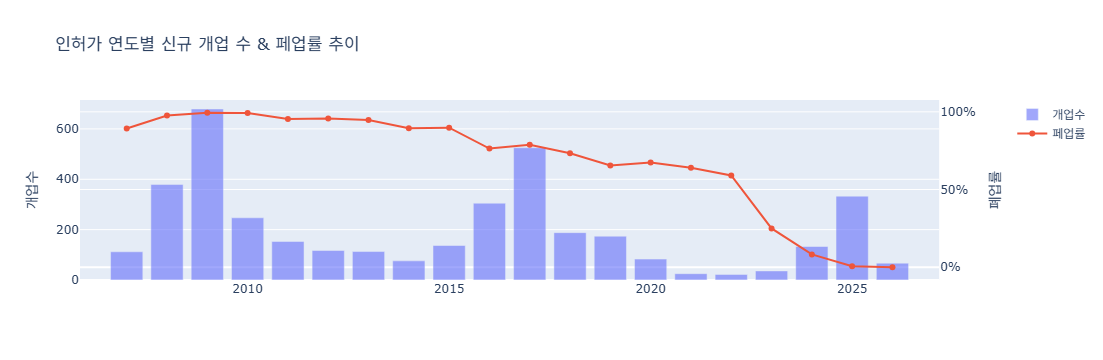

In [82]:
## 3-1-2. 인허가 연도별 신규 개업수 & 인허가 연도별 페업률 시각화

from plotly.subplots import make_subplots
import plotly.graph_objects as go

fig = make_subplots(specs=[[{'secondary_y' : True}]])  # secondary_y : True > 오른쪽에 y축을 추가 > 개업수와 폐업률의 단위가 달라서

# 개업수 막대차트
fig.add_trace(
    go.Bar(x=yearly_open['인허가연도'], y=yearly_open['개업수'], name='개업수', opacity=0.6),
    secondary_y=False)  #  # secondary_y=False : 왼쪽 y축 사용 (개업수)

# 폐업률 라인차트
fig.add_trace(
    go.Scatter(x=yearly_rate['인허가연도'],y=yearly_rate['폐업률'], name='페업률', mode='lines+markers'),
    secondary_y=True)   # secondary_y=True :  오른쪽 y축 사용 (폐업률)

fig.update_layout(title = '인허가 연도별 신규 개업 수 & 페업률 추이')
fig.update_yaxes(title_text = '개업수',secondary_y = False)
fig.update_yaxes(title_text = '폐업률',tickformat='.0%', secondary_y=True)
fig.show()

**인허가 연도별 신규 개업수 > 인허가 연도별 페업률**
- 1차 유행(2007 ~ 2009년) : 폐업률 거의 100% > 개업 많음 + 시간이 많이 지났으니 대부분 폐업 > 오락실 붐때 창업한 업소는 거의 다 폐업
- 2010~2015년 침체기 : 폐업률도 서서히 낮아짐
- 2차 유행(2016 ~ 2017년) : 폐업률 75~80% > 개업많음 + 시간 어느정도 지났으니 많이 폐업 > 인형뽑기 유행일때 창업한 업소 상당수 폐업
- 2017~2024년 침체기: 코로나 시기 개업 수가 급감 + 창업수 자체가 적기도하고 시간이 많이 지나지 않은게 폐업률에 복합적으로 영향을 미친듯
- 3차 유행(2024 ~ 현재) : 폐업률 낮음 > 개업많음 + 시간이 많이 지나지 않아서 아직 폐업이 적음 > 유행지나면 폐업률이 올라갈 가능성

> 유행에 편승한 창업은 유행 끝나면 폐업으로 이어지는 패턴, 현재 3차 유행중인 업소들도 같은 패턴을 따를 가능성

In [83]:
#3-2. 지역별 폐업률

# 폐업률 계산
district_rate = df_final.groupby('시군구').apply(lambda x: x['폐업여부'].sum()/len(x)).reset_index()
district_rate.columns = ['시군구','폐업률']
district_rate = district_rate.sort_values('폐업률', ascending=False)

print(district_rate)

     시군구       폐업률
23    중구  0.870690
10  동대문구  0.861111
9    도봉구  0.838323
7    금천구  0.837696
19  영등포구  0.836653
13  서대문구  0.828947
16   성북구  0.822660
4    관악구  0.804428
18   양천구  0.803571
5    광진구  0.786802
21   은평구  0.772727
6    구로구  0.770408
0    강남구  0.754545
17   송파구  0.733645
22   종로구  0.733333
2    강북구  0.732057
15   성동구  0.728814
1    강동구  0.720430
20   용산구  0.704545
14   서초구  0.697674
24   중랑구  0.683908
3    강서구  0.651079
8    노원구  0.635036
12   마포구  0.583333
11   동작구  0.487179


C:\Users\vhflv\AppData\Local\Temp\ipykernel_7504\1930903073.py:4: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



**지역별 폐업률**
- 중구(87%), 동대문구(86%)가 1,2위 : 유동인구도 많고, 폐업률도 높음 > 오피스 / 도매쇼핑 상권이라서? 임대료 또는 경쟁도 염두
- 동작구(48%)가 폐업률 최저 : 노량진 학원가 특성상 학생들이 많아서 수요가 있을 수도
- 강남구(75%)가 게임장 수도 적은데 폐업률이 높음

> 전체적으로 폐업률이 높은편. 2019년~현재까지의 데이터라 폐업한 업소가 많을 수 밖에 없을듯 + 코로나 영향 + 유행

In [84]:
# folium 시각화를 위해 Geojson 파일 구조 확인

import json

# Geojson URL
geo_url = 'https://raw.githubusercontent.com/southkorea/seoul-maps/master/kostat/2013/json/seoul_municipalities_geo_simple.json'

response = requests.get(geo_url)
geojson = response.json()

# 첫번째 피처속성 확인
print(geojson['features'][0]['properties'])

{'code': '11250', 'name': '강동구', 'name_eng': 'Gangdong-gu', 'base_year': '2013'}


In [85]:
# 지역별 폐업률 folium 시각화
import folium

# 지도 생성
m = folium.Map(location=[37.5665, 126.9780], zoom_start=11.3)  # 37.5665, 126.9780 서울시청 좌표 

# Choropleth
folium.Choropleth(
    geo_data = geo_url,          
    data = district_rate,
    columns = ['시군구','폐업률'],
    key_on = 'feature.properties.name',   
    fill_color = 'Blues',
    fill_opacity = 0.7,         
    line_opacity = 0.5,
    legend_name = '폐업률').add_to(m)

# 구 이름 표시하는 툴
folium.GeoJson(
    geojson,
    style_function = lambda x: {'fillopacity':0, 'weight':0},
    tooltip = folium.GeoJsonTooltip(fields=['name'],aliases=[''],sticky=True)).add_to(m)  # 툴팁에 표시될 라벨

m.save('seoul_closure_map.html')     
m

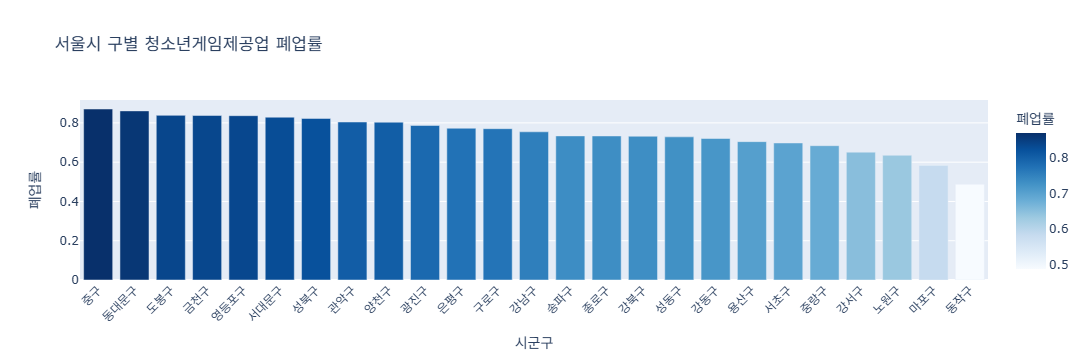

In [86]:
# 막대그래프 시각화
import plotly.express as px

fig = px.bar(district_rate,
             x='시군구',
             y='폐업률',
             title = '서울시 구별 청소년게임제공업 폐업률',
             color = '폐업률',
             color_continuous_scale = 'Blues')
fig.update_layout(xaxis_tickangle=-45)
fig.show()         

In [87]:
## 3-3. 역거리 vs 폐업 여부

# 폐업 여부 별 최근접역 거리 분포 확인
print(df_final.groupby('폐업여부')['최근접역_거리(m)'].describe())

       count        mean         std        min         25%         50%  \
폐업여부                                                                      
0      953.0  437.471133  272.109251  13.372145  263.409738  387.410552   
1     2956.0  464.160872  290.981097   5.475318  269.768964  395.337089   

             75%          max  
폐업여부                           
0     531.046509  2490.420741  
1     586.523338  1875.566018  


**역거리vs폐업여부 수치비교**
- 영업중 평균거리 437m / 폐업 평균거리 464m
- 거리가 27m 차이로 그리 크지 않음
- 역 거리만으로는 생존을 설명하기 어려울수도 > 거리보다 유동인구 규모가 더 중요할수도

> 27m의 차이가 통계적으로 의미가 있는지 확인필요

In [88]:
# 통계적 유의성 검정
from scipy import stats

group0 = df_final[df_final['폐업여부'] == 0]['최근접역_거리(m)']
group1 = df_final[df_final['폐업여부'] == 1]['최근접역_거리(m)']

stat, p = stats.mannwhitneyu(group0, group1)
print(f'p-value: {p: .4f}')

p-value:  0.0400


**p-value**
- p-value가 0.04 로 영업중 업소와 폐업한 업소의 역 거리 차이가 우연이 아닌 실제 차이일 가능성이 높음

> 폐업한 업소의 평균역 거리(464m)가 영업중인 업소(437m)보다 통계적으로 유의미하게 멀다. 역과의 거리가 업소 생존에 영향을 미치는 요인 중 하나인듯
>> 그런데 27m는 사실 큰 거리는 아님. 현실적인 영향력은 글쎄?

In [89]:
# 박스플롯 시각화
fig = px.box(
    df_final,
    x='폐업여부',
    y='최근접역_거리(m)',
    title = '폐업 여부 별 최근접역 거리 분포',
    labels={'폐업여부':'폐업여부( 0=영업중, 1=폐업 )'})

fig.show()

**폐업 여부 별 최근접역 거리 분포**
- 중앙값: 영업중 387m,폐업 395m로 폐업한 업소들이 역에서 조금 더 멀다
- 분산: 폐업한 업소의 거리 분산이 더 큼 > 가까운곳, 먼곳도 폐업 > 역거리만으론느 폐업을 설명하기 어려움?
- 이상치: 최대 이상치가 영업중 2490m, 폐업 1875m로 역에서 먼곳에도 영업중인 업소가 있음 > 입지가 좋지 않아도 살아남을 수 있다?

> 역과의 거리가 폐업에 영향을 미치긴하지만, IQR이 크고 이상치가 많은 것을 보면 역거리만으로는 폐업을 설명하기엔 한계가 있음. 다른 변수들도 봐야함

In [90]:
## 3-4. 유동인구 규모 VS 폐업 여부

# 폐업 여부 별 유동인구 분포 확인
print(df_final.groupby('폐업여부')['평균승하차인원'].describe())

       count          mean            std           min            25%  \
폐업여부                                                                     
0      953.0  1.410373e+06  833078.879626  50481.583333  858606.000000   
1     2956.0  1.325245e+06  763646.655373  50481.583333  764761.958333   

               50%          75%           max  
폐업여부                                           
0     1.345999e+06  1555231.375  4.586252e+06  
1     1.345999e+06  1555231.375  4.586252e+06  


In [91]:
# 50% ~ 그 이후는 영업중과 폐업의 데이터가 동일함  > 지하철 9호선 등 결측치를 평균으로 대체해서 데이터가 왜곡된듯
# 일단 p-value 확인
from scipy import stats

group0 = df_final[df_final['폐업여부'] == 0]['평균승하차인원']
group1 = df_final[df_final['폐업여부'] == 1]['평균승하차인원']

stat, p = stats.mannwhitneyu(group0, group1)
print(f'p-value: {p:.4f}')

p-value: 0.0396


In [98]:
# p-value는 유의미한것으로 보임
# 미매칭역의 다른 승하차 데이터를 찾아서 대체가 필요할듯  > '서울시 지하철호선별 역별 승하차 인원 정보' 2025년 데이터로 평균으로 대체했던 결측치만 대체

## 3-5-1 역별 승하차인원 결측치 추가 대체
# 데이터 확인
import glob

files_new = glob.glob('지하철_승하차_보완(25년)승하차/*.csv')
temp = pd.read_csv(files_new[0], encoding='UTF-8-SIG')

print(temp.columns.tolist())
temp.tail()

['사용일자', '노선명', '역명', '승차총승객수', '하차총승객수', '등록일자']


,사용일자,노선명,역명,승차총승객수,하차총승객수,등록일자
20250131,수인선,남동인더스파크,1622,1748,20250203,NaN
20250131,수인선,원인재,3834,3942,20250203,NaN
20250131,수인선,연수,4170,4016,20250203,NaN
20250131,수인선,송도,2076,1848,20250203,NaN
20250131,수인선,인하대,5245,4854,20250203,NaN


In [99]:
# 25년 파일 12개 합치기

new_list = []

for file in files_new:
    try:
        temp = pd.read_csv(file, encoding='UTF-8-SIG', index_col=False)
    except:
        temp = pd.read_csv(file, encoding='cp949', index_col=False)
    new_list.append(temp)

new_subway_df = pd.concat(new_list, ignore_index=True)

# 승하차인원 합치기
new_subway_df['승하차인원'] = new_subway_df['승차총승객수'] + new_subway_df['하차총승객수']

# 승하차인원 역별 평균
new_subway_avg = new_subway_df.groupby('역명')['승하차인원'].mean().reset_index()
new_subway_avg.columns = ['역명', '평균승하차인원']

print(new_subway_avg.shape)
print(new_subway_avg.head())

(532, 2)
         역명       평균승하차인원
0  4.19민주묘지   6936.835165
1        가능  12221.054945
2      가락시장  17121.884615
3   가산디지털단지  54860.028846
4        가양  42000.381868


In [100]:
# 기존에 평균으로 대체했던 역 목록
missing_mask = df['평균승하차인원'] == mean_subway
missing_stations = df[missing_mask]['최근접역명'].unique()

print(f'미매칭역 종류: {len(missing_stations)}개')
print(missing_stations[:10])

미매칭역 종류: 62개
['서울' '남영' '용산' '한남' '서빙고' '서울숲' '뚝섬유원지' '외대앞' '회기' '중랑']


In [101]:
# 새 데이터에서 미매칭 역만 추출
new_subway_final = new_subway_avg[new_subway_avg['역명'].isin(missing_stations)]

print(f'새 데이터에서 매칭된 수: {len(new_subway_final)}개')
print(new_subway_final.head())

새 데이터에서 매칭된 수: 56개
          역명       평균승하차인원
0   4.19민주묘지   6936.835165
4         가양  42000.381868
5        가오리   8347.368132
6         가좌  11210.442308
20        개봉  42173.502747


In [102]:
# 여천히 미매칭인 역 6개 확인
matched = new_subway_avg['역명'].tolist()
still_missing = [i for i in missing_stations if i not in matched]

print(f'여전히 미매칭 : {len(still_missing)}개')
print(still_missing)

여전히 미매칭 : 6개
['서울', '뚝섬유원지', '마곡나루', '흑석', '양재시민의숲', '총신대입구']


In [103]:
# 새 데이터에서 비슷한 역명 검색

for station in still_missing:
    matches = new_subway_avg[new_subway_avg['역명'].str.contains(station[:2])]
    print(f'{station} → {matches["역명"].tolist()}')

서울 → ['강변(동서울터미널)', '경복궁(정부서울청사)', '공릉(서울과학기술대)', '관악산(서울대)', '마곡나루(서울식물원)', '미아(서울사이버대학)', '봉화산(서울의료원)', '서울대벤처타운', '서울대입구(관악구청)', '서울숲', '서울역', '서울지방병무청', '청량리(서울시립대입구)', '화랑대(서울여대입구)']
뚝섬유원지 → ['뚝섬', '자양(뚝섬한강공원)']
마곡나루 → ['마곡', '마곡나루(서울식물원)']
흑석 → ['흑석(중앙대입구)']
양재시민의숲 → ['양재(서초구청)']
총신대입구 → ['총신대입구(이수)']


In [104]:
# 역명 매핑
station_mapping = {
    '서울': '서울역',
    '뚝섬유원지': '뚝섬',
    '마곡나루': '마곡나루(서울식물원)',
    '흑석': '흑석(중앙대입구)',
    '양재시민의숲': '양재(서초구청)',
    '총신대입구': '총신대입구(이수)'}

# df '최근접역명'에 매핑 적용
df['최근접역명'] = df['최근접역명'].replace(station_mapping)

# 미매칭인 역만 새 데이터로 보완
for _, row in new_subway_avg.iterrows():     
    mask = (df['최근접역명'] == row['역명']) & (df['평균승하차인원'] == mean_subway)
    df.loc[mask, '평균승하차인원'] = row['평균승하차인원']

# 확인
print(f'결측치(평균대체) 남은 수: {(df["평균승하차인원"] == mean_subway).sum()}')
print(f'데이터 수 : {len(df)}개')

결측치(평균대체) 남은 수: 0
데이터 수 : 3909개


In [105]:
# df_final 다시 만들기
final_cols = ['폐업여부','시군구','인허가연도','생존기간(일)','시설면적',
              '업소위도','업소경도','최근접역_거리(m)','최근접역명',
              '500m내_역수','평균승하차인원','접근성그룹']

df_final = df[final_cols].copy()

In [106]:
# 폐업 여부 별 유동인구 분포 재확인
print(df_final.groupby('폐업여부')['평균승하차인원'].describe())

       count          mean           std          min            25%  \
폐업여부                                                                   
0      953.0  1.097163e+06  1.024882e+06  3392.428571  221886.416667   
1     2956.0  1.000468e+06  9.436327e+05  3392.428571   90105.063187   

                50%          75%           max  
폐업여부                                            
0     887279.583333  1555231.375  4.586252e+06  
1     764761.958333  1555231.375  4.586252e+06  


In [107]:
# 미매칭 역 중 56개를 추가 데이터로 보완했으나, 일부는 여전히 평균값으로 대체되어 상위 분포에 왜곡이 남아있음 > 이대로진행

# p_value 확인
from scipy import stats

group0 = df_final[df_final['폐업여부'] == 0]['평균승하차인원']
group1 = df_final[df_final['폐업여부'] == 1]['평균승하차인원']

stat, p = stats.mannwhitneyu(group0, group1)
print(f'p-value: {p:.4f}')

p-value: 0.0662


**폐업여부와 평균승하차 인원 p-value 결과**
- 실제 다른 데이터로 결측치를 보완했더니 p-value가 0.06으로 통계적 유의성이 사라짐 > 유동인구 단독으로는 폐업 여부를 충분히 설명하지 못함 > 역거리, 시설면적 등 다른 변수와 함께 봐야함

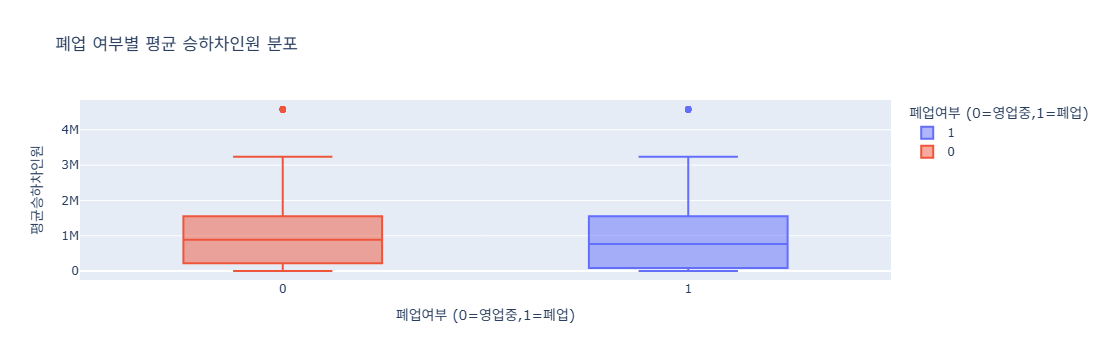

In [108]:
# 폐업여부와 승하차인원 박스플롯 시각화

fig = px.box(
    df_final,
    x = '폐업여부',
    y = '평균승하차인원',
    title = '폐업 여부별 평균 승하차인원 분포',
    labels = {'폐업여부':'폐업여부 (0=영업중,1=폐업)'},
    color = '폐업여부')

fig.show()

**유동인구 규모 VS 폐업 여부 시각화**
- 영업중인 업소의 중앙값(887,279)이 페업 업소(764,762)보다 높음 > 영업중인 업소 주변이 유동인구가 더 많은 경향
- 폐업 업소의 박스가 더 넓음 > 유동인구 분포가 더 넒음> '유동인구가 많은곳도 적은곳도 폐업함'
- 두 그룹 모두 상단에 이상치 존재 > 극단적으로 유동인구가 많은 역 주변에도 페업한 업소가 있음

> 영업중 업소의 유동인구 중앙값이 더 높지만, 통계적으로 유의미하지않아서 유동인구 단독으로는 폐업을 설명하기 어려움 (p-value가 0.066)

> 유동인구가 많아도 페업하는 케이스도 있어서 다른 변수와의 복합적인 분석이 필요할듯

In [109]:
## 3-5. 유동인구 × 역 거리 조합 패턴

# 접근성 그룹별 폐업률 계산
group_rate = df_final.groupby('접근성그룹').apply(lambda x: x['폐업여부'].sum() / len(x)).reset_index()
group_rate.columns = ['접근성그룹','폐업률']
print(group_rate)

  접근성그룹       폐업률
0  고접근성  0.732308
1    기타  0.768382
2  저접근성  0.751979


C:\Users\vhflv\AppData\Local\Temp\ipykernel_7504\3247425478.py:4: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [110]:
# 2~4% 차이로 접근성이 높은그룹과 낮은 그룹에 큰 차이가 없음
# 통계적으로 유의미한지 확인

고접근성 = df_final[df_final['접근성그룹'] == '고접근성']['폐업여부']
저접근성 = df_final[df_final['접근성그룹'] == '저접근성']['폐업여부']

stat, p = stats.mannwhitneyu(고접근성,저접근성)
print(f'p=value : {p:.4f}')

p=value : 0.3540


**접근성과 폐업여부의 p-value 결과**
- p-value 0.3395로 통계적으로 유의미하지않았음
> 역거리와 유동인구를 조합한 접근성 지표만으로는 폐업을 충분히 설명하기 어려움

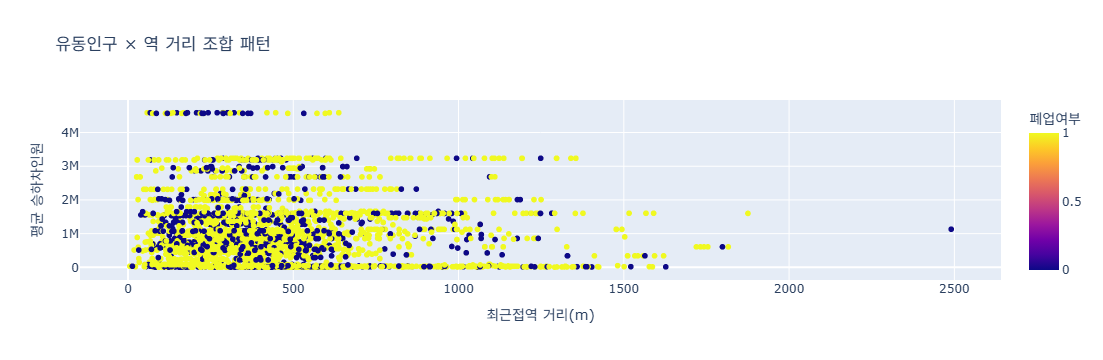

In [111]:
# 유동인구 × 역 거리 산점도 시각화

fig = px.scatter(
    df_final,
    x='최근접역_거리(m)',
    y='평균승하차인원',
    color='폐업여부',
    title='유동인구 × 역 거리 조합 패턴',
    labels={'최근접역_거리(m)': '최근접역 거리(m)',
            '평균승하차인원': '평균 승하차인원',
            '폐업여부': '폐업여부'},
    opacity=1
)
fig.show()

**유동인구x역거리 조합 패턴**
- 폐업한 업소가 압도적으로 많아서 영업중인 업소가 잘안보임
- 대부분의 업소가 역 500m 내, 승하차인원 1M~3M 간에 집중되어있음
- 역에서 멀어질수록 업소 자체가 급감 > 입지 선택이 역세권 중심인듯
- 500m 이내 유동인구가 많은 구간에도 폐업이 많음 > 좋은 입지라도 폐업을 막지 못함
- 역 거리 1000m 이상에도 폐업과 영업중인 업소가 혼재 > 거리 단독으로는 생존 설명이 어려움
- 유동인구많음+근거리, 유동인구적음+원거리에도 생존업소 존재 > 영업중인 업소들의 뚜렷한 패턴은 보이지 않음

> 이전 결과(역거리 p=0.04(거리차 27m), 유동인구 p=0.066, 조합 p=0.34과 산점도를 같이 보면, 접근성 변수가 통계적으로 설명력이 약함
> 생존을 결정하는 다른 요인이 더 클 가능성

In [112]:
## 3-6. 시설면적 vs 폐업여부

# 데이터 확인
print(df_final.groupby('폐업여부')['시설면적'].describe())

       count        mean        std  min   25%      50%     75%     max
폐업여부                                                                   
0      953.0   60.233610  49.576021  6.6  29.0   39.860   74.38  285.00
1     2956.0  106.768383  57.612280  1.0  60.0  107.595  143.82  285.98


In [113]:
# 영업중인 업소보다 폐업한 업소의 평균 면적이 거의 2배 차이 남
# 면적이 클수록 임대로가 높으니 임대로 영향일수도

# 통계적 유의성 확인
영업중 = df_final[df_final['폐업여부'] == 0]['시설면적']
폐업 = df_final[df_final['폐업여부'] == 1]['시설면적']

stat, p = stats.mannwhitneyu(영업중,폐업)
print(f'p-value : {p:.4f}')

p-value : 0.0000


In [114]:
# p-value가 너무 작은가보다  > 어쨋든 통계적으로 유의미함 
print(f'p-value : {p:.2e}')

p-value : 1.17e-109


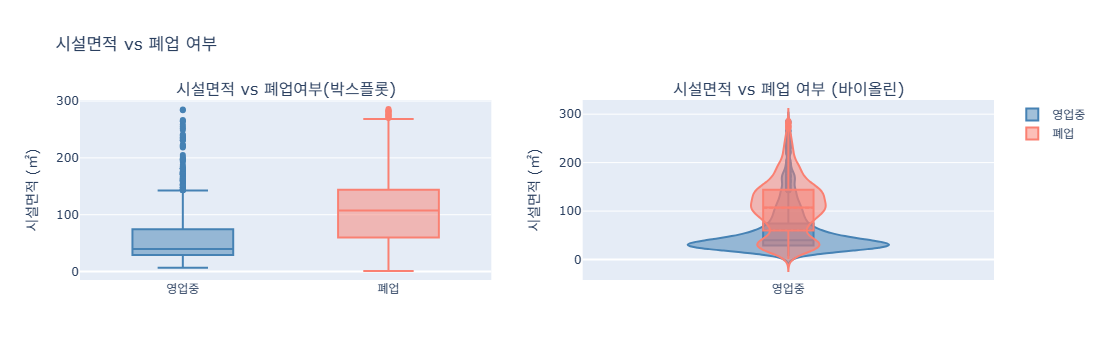

In [115]:
# 시각화 > 데이터 값이 너무 달라서 박스플롯+바이올린 플롯으로 보기

fig = make_subplots(rows=1, cols=2, subplot_titles=['시설면적 vs 폐업여부(박스플롯)', '시설면적 vs 폐업 여부 (바이올린)']) 

# 박스플롯
fig.add_trace(go.Box(y=영업중, name='영업중', marker_color = 'steelblue'), row=1, col=1)
fig.add_trace(go.Box(y=폐업, name='폐업', marker_color = 'salmon'), row=1, col=1)

# 바이올린
fig.add_trace(go.Violin(y=영업중, name='영업중', box_visible=True, meanline_visible=True, marker_color='steelblue',showlegend=False),row=1, col=2) 
fig.add_trace(go.Violin(y=폐업, name='영업중', box_visible=True, meanline_visible=True, marker_color='salmon',showlegend=False),row=1, col=2)  

fig.update_layout(title= '시설면적 vs 폐업 여부')
fig.update_yaxes(title_text='시설면적 (㎡)', col=1)
fig.update_yaxes(title_text='시설면적 (㎡)', col=2)

fig.show()

**시설면적 vs 폐업여부**

- 폐업 업소의 중앙값이 영업중인 업소보다 약 2.7배 크고, 분산도 2배정도 큼 > 폐업 업소의 면적은 다양하게 분포
- 영업중인 업소는 대부분 100㎡ 이하에 집중, 특히 30~40㎡ 에 집중되어있음
> 요새는 규모가 작지만 예전에는 대형 오락실이 많았음 > 오래된 업소일수록 페업률이 높아서 이부분에서 혼란이 있을 가능성

In [116]:
## 3-6-1 인허가연도 vs 시설면적
# 오래된 업소일 수록 면적이 큰지 확인해보기

# 데이터 확인
print(df_final.groupby('인허가연도')['시설면적'].describe())

       count        mean        std    min      25%      50%       75%     max
인허가연도                                                                         
1998     1.0   18.900000        NaN  18.90  18.9000   18.900   18.9000   18.90
2001     1.0   50.000000        NaN  50.00  50.0000   50.000   50.0000   50.00
2003     1.0   22.500000        NaN  22.50  22.5000   22.500   22.5000   22.50
2005     2.0  100.590000  86.564012  39.38  69.9850  100.590  131.1950  161.80
2007   112.0  117.281339  46.819247   1.00  82.5900  117.110  145.2625  249.00
2008   379.0  126.117493  50.337970   1.00  94.4200  120.920  148.7050  281.10
2009   679.0  126.097644  43.863458   9.34  98.8700  119.470  148.1500  285.98
2010   247.0  123.679676  41.019136  12.00  99.7200  122.310  142.6400  281.10
2011   153.0  117.993529  49.547401  11.04  83.5200  109.170  151.0400  285.00
2012   117.0  127.127179  44.744708  38.64  98.4600  123.570  149.5200  272.77
2013   113.0  127.530442  49.208048  33.93  90.0000 

**인허가연도 vs 시설면적 데이터**
- 평균을 보면 2007~2015년 면적이 일관되게 높음 / 2016년 이후 절반으로 줄어듬
> 면적이 큰게 폐업에 영향을 미치는게 아니라, 오래된 대형 업소들이 폐업했던것

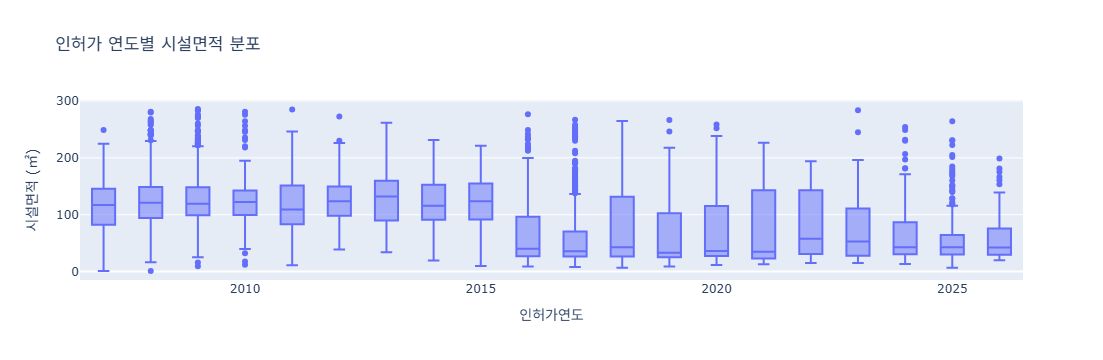

In [117]:
# 인허가연도 vs 시설면적 시각화
# ~2005년 데이터는 수가 적으니까 제거 하고 보기

fig = px.box(
    df_final[df_final['인허가연도'] >= 2007],
    x = '인허가연도',
    y = '시설면적',
    title = '인허가 연도별 시설면적 분포')
fig.update_layout(xaxis_title='인허가연도', yaxis_title='시설면적 (㎡)')

fig.show()

**시설면적 vs 폐업여부 + 인허가연도 vs 시설면적 시각화**
- 시설면적과 폐업의 관계는 면적 자체보다 인허가 시기가 핵심 교란 변수임
- 2016년 이전 대형 업소들의 폐업률을 끌어 올리고 있을 가능성이 높음

### EDA 정리

① 연도별 신규 개업 패턴

- 3차례 개업 유행 확인: 2007 ~ 2009 / 2016 ~ 2017 / 2024 ~ 2026 현재 다시 상승중

② 인허가 시기와 폐업률

- 오래된 연도일수록 폐업률이 높음
- 시간 경과 자체가 폐업과 강하게 연관

③ 역 거리와 폐업

- 폐업 평균 464m vs 영업중 437m, p=0.04로 통계적으로 유의미 > 단, 27m 차이로 실질적 효과 크기는 작음
- 역 거리 단독으로 생존 설명에는 한계

④ 유동인구와 폐업

- p=0.066으로 유의미하지 않음 > 유동인구 단독으로 폐업 설명 어려움

⑤ 역 거리 × 유동인구 조합

- 고접근성 73.3% vs 저접근성 75.3%, p=0.34
- 두 변수를 조합해도 폐업 설명력 없음
- "좋은 입지가 생존을 보장하지 않는다" 는 게 일관된 패턴

⑥ 시설면적과 폐업

- 폐업 중앙값 107.6㎡ vs 영업중 39.9㎡, p≈0 으로 매우 유의미
- 영업중 업소는 소규모 중심, 폐업 업소는 다양한 면적 분포

⑦ 인허가연도별 시설면적

- 2007 ~ 2015년 개업 업소는 중앙값 109 ~ 132㎡의 대형 업소 중심
- 2016년 이후 중앙값 35~57㎡로 급격히 소형화
- ⑥의 시설면적-폐업 관계는 인허가 시기가 교란변수로 작용할 가능성 > 대형 업소가 많던 시기의 업소들이 폐업률도 높기 때문